# Equity Analyst Forecasted Returns

In [28]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
sig_path  = os.getcwd()
res_path  = os.path.abspath(os.path.join(sig_path, ".."))
repo_path = os.path.abspath(os.path.join(res_path, ".."))
data_path = os.path.join(repo_path, "data")
fut_path  = os.path.join(data_path, "FuturesData")

In [3]:
path   = r"A:\2026BlpAdHocData\Combined\Equity"
files  = [os.path.join(path, file) for file in os.listdir(path) if file.split(".")[0][-3:-1] =="es"] 
df_raw = (pd
    .read_parquet(path = path, engine = "pyarrow"))

In [4]:
keep_fields = (df_raw
    [["field"]]
    .drop_duplicates()
    .assign(tmp = lambda x: x.field.str.split("_").str[0])
    .loc[lambda x: x.tmp == "BEST"]
    .field
    .to_list())

In [5]:
df_keep_fields  = (df_raw
    .loc[lambda x: x.field.isin(keep_fields)]
    .drop_duplicates())

In [6]:
guide_path = os.path.join(data_path, "TickerGuide.xlsx")
df_ticker  = (pd
    .read_excel(io = guide_path, sheet_name = "fut_guide")
    .loc[lambda x: x.group == "equity"]
    [["Tmp", "Front", "bloomberg_underlying"]]
    .rename(columns = {
        "Tmp"                 : "name",
        "Front"               : "front",
        "bloomberg_underlying": "bbg_underlying"})
    .assign(ticker = lambda x: x.front.str.replace(" 1", "1").str.replace(" ", "_").str.lower())
    .sort_values("front")
    .replace({"INDU Index": "DJUST Index"}))

In [7]:
df_est = (df_keep_fields
    .rename(columns = {"security": "bbg_underlying"})
    .merge(right = df_ticker, how = "inner", on = ["bbg_underlying"]))

In [8]:
def _get_signal(df: pd.DataFrame, window: int = 100) -> pd.DataFrame: 

    df_out = (df
        .sort_values("date")
        .assign(
            R          = lambda x: x.value.diff() / x.value.diff().ewm(span = 10, adjust = False).std(),
            signal     = lambda x: x.R.ewm(span = window, adjust = False).mean(),
            lag_signal = lambda x: x.signal.shift()))

    return df_out
    
window = 100

df_signal = (df_est
    .assign(group_var = lambda x: x.field + "-" + x.ticker)
    .groupby("group_var")
    .apply(_get_signal, window)
    .reset_index(drop = True))

In [9]:
tickers = df_signal.ticker.drop_duplicates().sort_values().to_list()

In [10]:
px_path = os.path.join(fut_path, "PrepFuturesPX.parquet")
df_px   = (pd
    .read_parquet(path = px_path, engine = "pyarrow")
    [["date", "ticker", "adj_val"]]
    .dropna()
    .rename(columns = {"adj_val": "px"}))

In [11]:
def _get_trend(df: pd.DataFrame, window: int = 100) -> pd.DataFrame: 
    
    df_out = (df
        .sort_values("date")
        .assign(
            px_rtn     = lambda x: x.px.pct_change(),
            R          = lambda x: x.px.diff() / x.px.diff().ewm(span = 10, adjust = False).std(),
            signal     = lambda x: x.R.ewm(span = 100, adjust = False).mean(),
            lag_signal = lambda x: x.signal.shift()))

    return df_out

window      = 100
df_px_trend = (df_px
    .loc[lambda x: x.ticker.isin(tickers)]
    .groupby("ticker")
    .apply(_get_trend, window)
    .reset_index()
    .drop(columns = ["level_1"]))

In [12]:
df_right = (df_px_trend
    .assign(date = lambda x: pd.to_datetime(x.date).dt.date)
    [["date", "ticker", "lag_signal", "px_rtn"]]
    .dropna())

In [13]:
df_combined = (df_signal
    .assign(date = lambda x: pd.to_datetime(x.date).dt.date)
    [["date", "field", "lag_signal", "ticker"]]
    .pivot(index = ["date", "ticker"], columns = "field", values = "lag_signal")
    .reset_index()
    .merge(right = df_right, how = "inner", on = ["date", "ticker"])
    .rename(columns = {"lag_signal": "px_trend"}))

In [14]:
df_signal_rtn = (df_combined
    .melt(id_vars = ["date", "ticker", "px_rtn"])
    .dropna()
    .assign(signal_rtn = lambda x: np.sign(x.value) *  x.px_rtn))

In [73]:
df_corr = (df_combined
    .drop(columns = ["px_rtn"])
    .melt(id_vars = ["date", "ticker", "px_trend"])
    .drop(columns = ["date"])
    .dropna()
    .groupby(["ticker", "variable"])
    .agg("corr")
    .loc[lambda x: x.value != 1])

(df_corr
    .reset_index()
    .pivot(index = "ticker", columns = "variable", values = "value"))

variable,BEST_CALCULATED_FCF,BEST_CUR_EV_TO_EBITDA,BEST_DIV_YLD,BEST_EBIT,BEST_EPS,BEST_GROSS_MARGIN,BEST_PE_RATIO,BEST_PX_SALES_RATIO,BEST_TARGET_PRICE
ticker,,,,,,,,,
dm1_index,0.071539,0.686167,-0.596398,0.096086,0.229656,0.061507,0.623872,0.809876,0.456635
es1_index,-0.133350,0.721777,-0.894640,0.184945,0.383061,0.215144,0.838149,0.920541,0.592445
nq1_index,0.224257,0.000082,-0.698042,0.395529,0.419900,0.095059,0.838307,0.754634,0.661925
rty1_index,0.057796,0.568876,-0.526335,-0.129867,-0.003038,-0.233046,0.453913,0.738652,0.470639


In [16]:
df_vol_rtn = (df_signal_rtn
    .drop(columns = ["value", "px_rtn"])
    .set_index("date")
    .groupby(["ticker", "variable"])
    .apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252))))
    .rename(columns = {"signal_rtn": "vol_rtn"})
    .reset_index())

In [17]:
df_cuml = (df_vol_rtn
    .set_index("date")
    .groupby(["ticker", "variable"])
    .apply(lambda x: x.vol_rtn.rolling(window = 30).sum())
    .reset_index()
    .rename(columns = {
        "vol_rtn" : "cuml_rtn",
        "variable": "field"})
    .dropna())

In [18]:
df_cuml_combined = (df_signal
    [["date", "field", "ticker", "signal"]]
    .assign(date = lambda x: pd.to_datetime(x.date).dt.date)
    .merge(right = df_cuml, how = "inner", on = ["date", "field", "ticker"]))

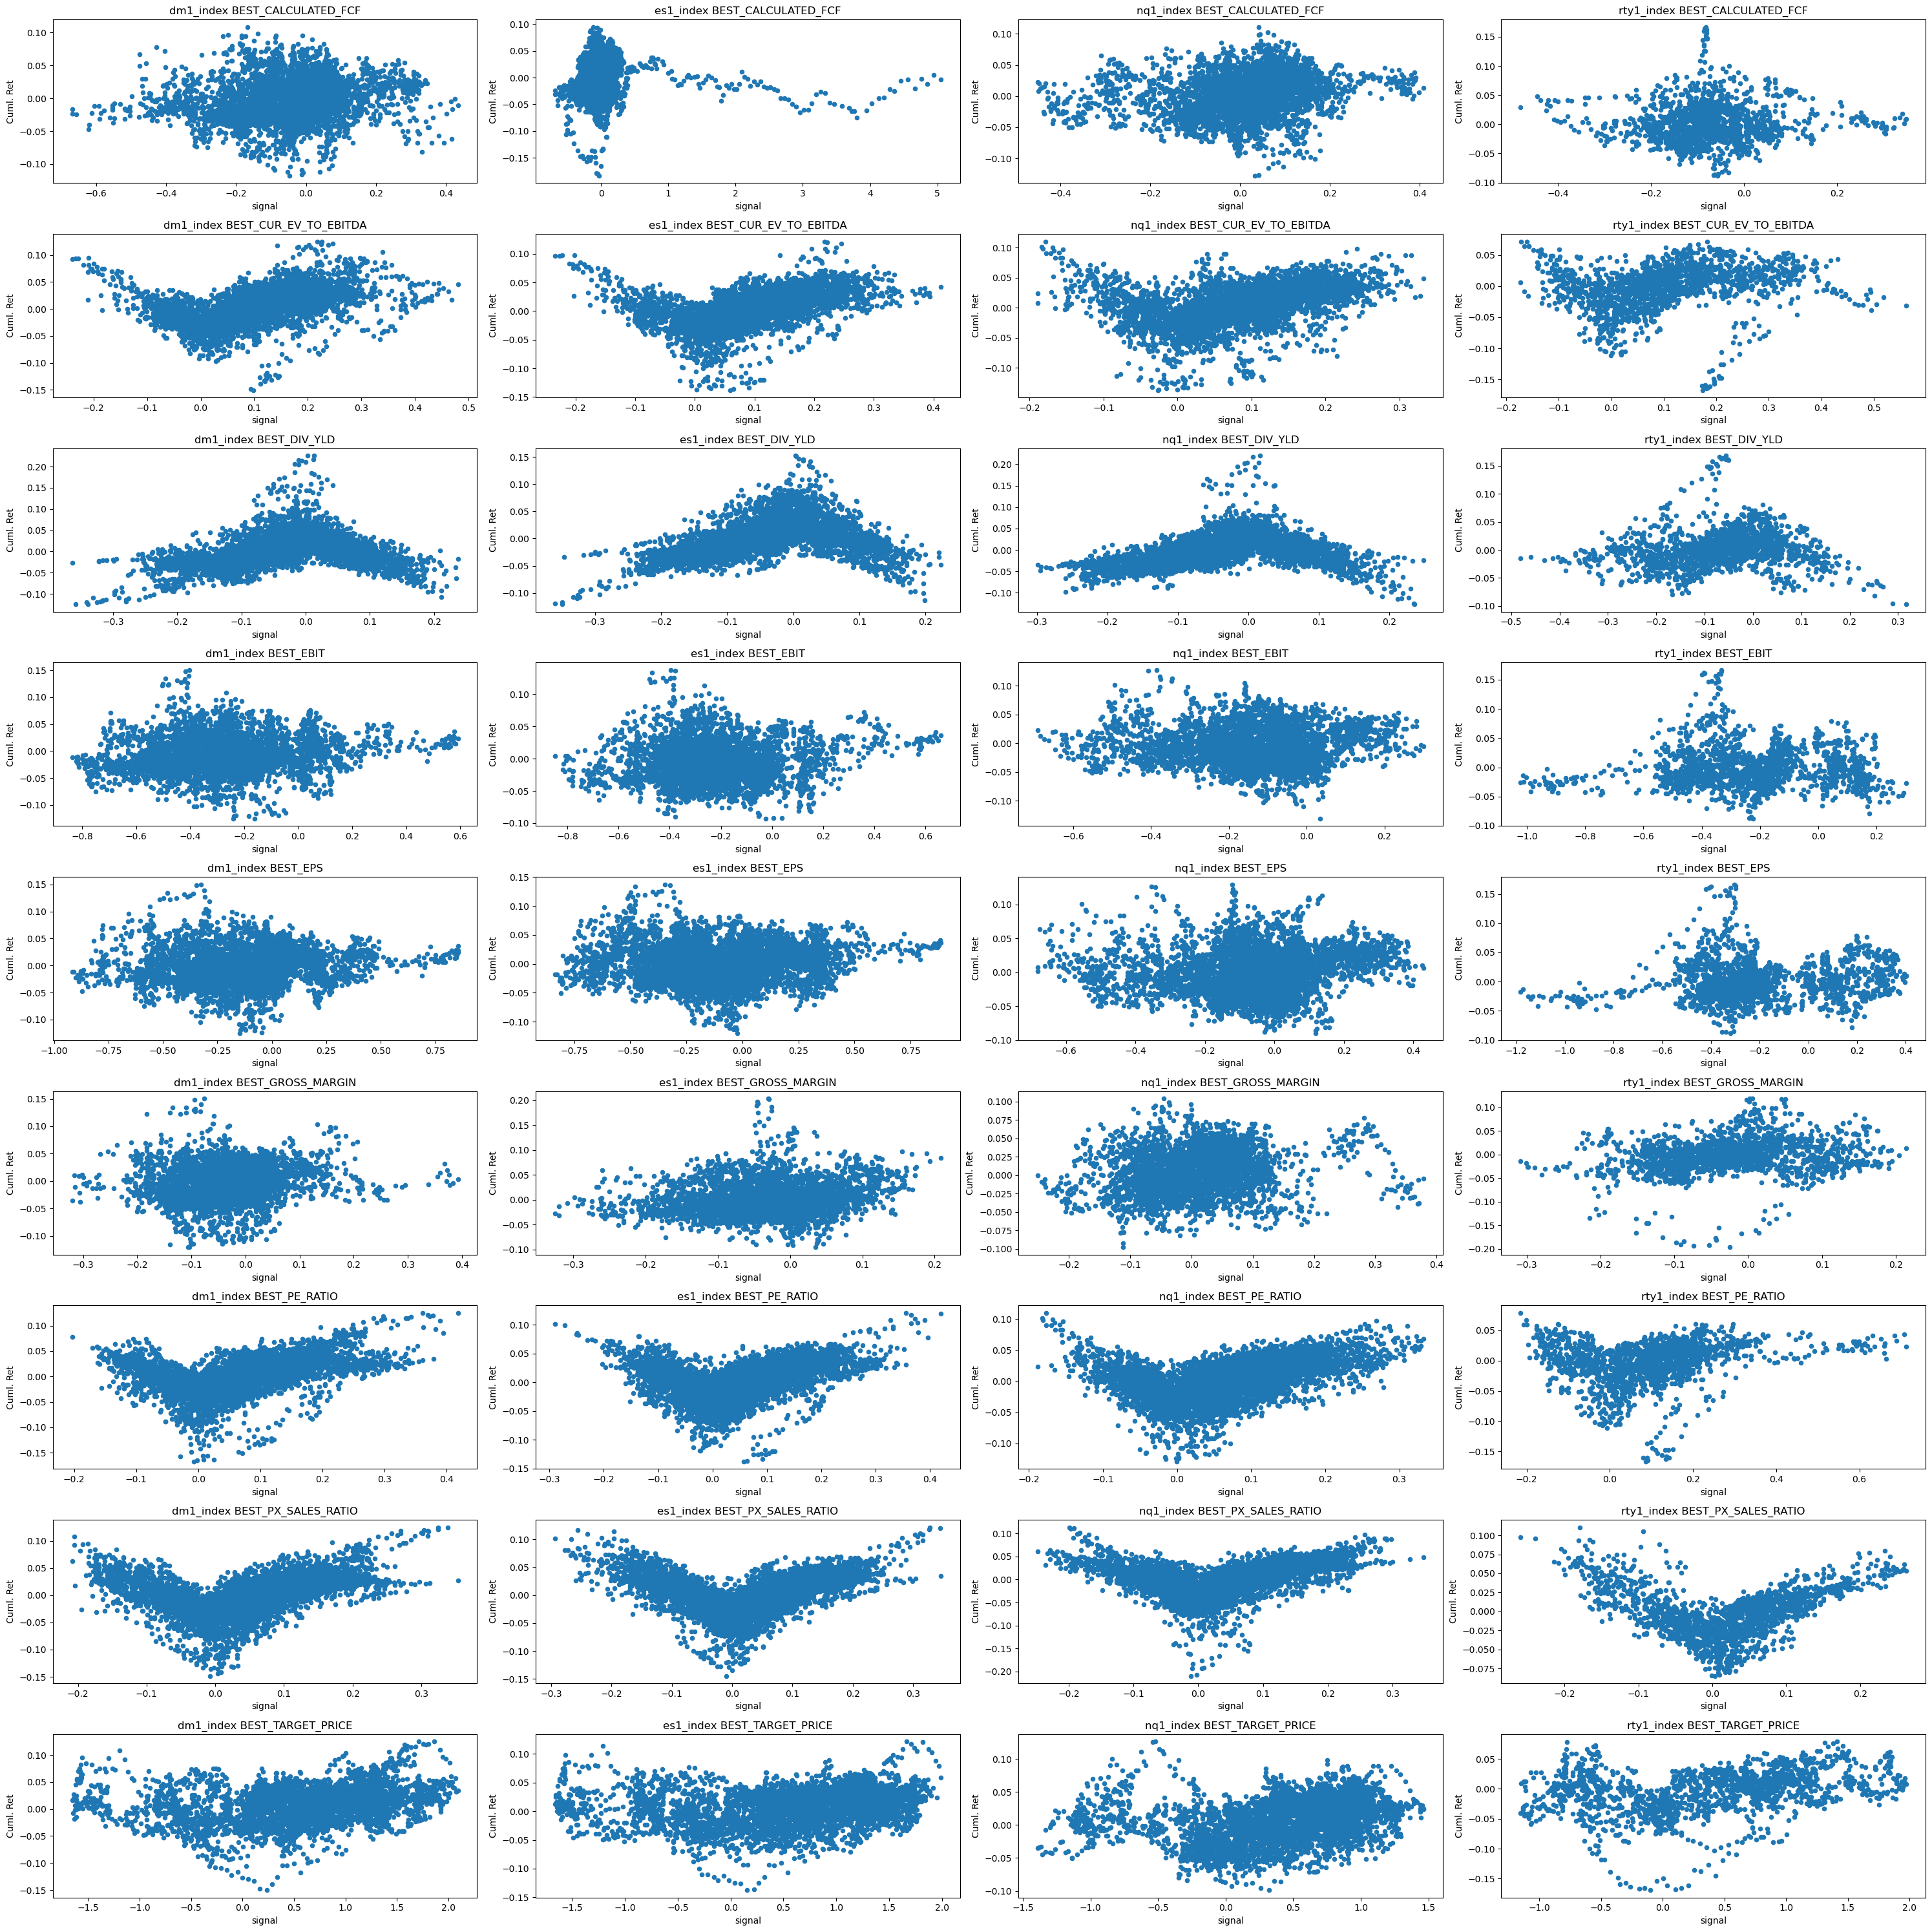

In [19]:
fields    = df_cuml_combined.field.drop_duplicates().sort_values().to_list()
tickers   = df_cuml_combined.ticker.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(tickers), nrows = len(fields), figsize = (30,30)) 

for j, ticker in enumerate(tickers):
    for i, field in enumerate(fields): 
    
        (df_cuml_combined
            .loc[lambda x: x.field == field]
            .loc[lambda x: x.ticker == ticker]
            .assign(year = lambda x: pd.to_datetime(x.date).dt.year)
            .loc[lambda x: x.year != x.year.min()]
            .plot(
                ax     = axes[i,j],
                kind   = "scatter", 
                x      = "signal", 
                y      = "cuml_rtn",
                ylabel = "Cuml. Ret",
                title  = "{} {}".format(ticker, field)))

plt.tight_layout()

In [41]:
df_vol_rtn = (df_px
    .pivot(index = "date", columns = "ticker", values = "px")
    .pct_change()
    .apply(lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252))))
    .reset_index()
    .melt(id_vars = "date", value_name = "vol_rtn")
    .dropna())

In [56]:
def _measure_convexity(df: pd.DataFrame) -> pd.DataFrame: 

    model = (sm
        .OLS(
            endog = df.px_rtn,
            exog  = sm.add_constant(df[["signal", "sig_sq"]]))
        .fit())

    df_param_val  = model.params.to_frame(name = "param_val").reset_index()
    df_pvalue_val = model.pvalues.to_frame(name = "p_value").reset_index()
    df_tvalue_val = model.tvalues.to_frame(name = "t_value").reset_index()

    df_out = (df_param_val
        .merge(right = df_pvalue_val, how = "inner", on = ["index"])
        .merge(right = df_tvalue_val, how = "inner", on = ["index"])
        .rename(columns = {"index": "param"}))

    return df_out

df_convexity_measure = (df_combined
    .melt(id_vars = ["date", "ticker", "px_rtn"])
    .dropna()
    .set_index("date")
    .rename(columns = {"value": "signal"})
    .merge(right = df_vol_rtn, how = "inner", on = ["ticker", "date"])
    .assign(
        sig_sq = lambda x: x.signal ** 2,
        name   = lambda x: x.ticker + "-" + x.variable)
    .groupby("name")
    .apply(_measure_convexity))

In [90]:
df_corr_tmp = (df_corr
    .reset_index()
    .drop(columns = ["level_2", "px_trend"])
    .rename(columns = {
        "variable": "field",
        "value"   : "corr_val"}))

In [98]:
(df_convexity_measure
    .reset_index()
    .loc[lambda x: x.param == "sig_sq"]
    .drop(columns = ["level_1", "p_value", "param"])
    .assign(
        ticker = lambda x: x.name.str.split("-").str[0],
        field  = lambda x: x.name.str.split("-").str[1])
    .drop(columns = ["name"])
    .merge(right = df_corr_tmp, how = "inner", on = ["ticker", "field"])
    .melt(id_vars = ["ticker", "field"])
    .pivot(index = ["ticker", "field"], columns = "variable", values = "value"))

variable                          corr_val  param_val   t_value
ticker     field                                               
dm1_index  BEST_CALCULATED_FCF    0.071539   0.000333  0.114061
           BEST_CUR_EV_TO_EBITDA  0.686167   0.008517  0.774290
           BEST_DIV_YLD          -0.596398  -0.000990 -0.318809
           BEST_EBIT              0.096086   0.002105  1.378371
           BEST_EPS               0.229656   0.000557  0.405348
           BEST_GROSS_MARGIN      0.061507  -0.001525 -0.367967
           BEST_PE_RATIO          0.623872   0.003581  0.888609
           BEST_PX_SALES_RATIO    0.809876   0.012049  1.177916
           BEST_TARGET_PRICE      0.456635  -0.000049 -0.718795
es1_index  BEST_CALCULATED_FCF   -0.133350   0.000052  1.067061
           BEST_CUR_EV_TO_EBITDA  0.721777   0.000960  0.119041
           BEST_DIV_YLD          -0.894640   0.022878  1.405222
           BEST_EBIT              0.184945   0.003310  1.330561
           BEST_EPS               0.383061   0.000940  0.623882
           BEST_GROSS_MARGIN      0.215144   0.009475  1.559583
           BEST_PE_RATIO          0.838149   0.015330  1.222984
           BEST_PX_SALES_RATIO    0.920541   0.011684  0.952545
           BEST_TARGET_PRICE      0.592445  -0.000046 -0.671121
nq1_index  BEST_CALCULATED_FCF    0.224257   0.003548  0.552427
           BEST_CUR_EV_TO_EBITDA  0.000082   0.000055  0.662101
           BEST_DIV_YLD          -0.698042  -0.004038 -0.898428
           BEST_EBIT              0.395529   0.002781  0.599374
           BEST_EPS               0.419900   0.000868  0.205706
           BEST_GROSS_MARGIN      0.095059   0.001043  0.319411
           BEST_PE_RATIO          0.838307  -0.003349 -0.172249
           BEST_PX_SALES_RATIO    0.754634  -0.001975 -0.271035
           BEST_TARGET_PRICE      0.661925  -0.000032 -0.062420
rty1_index BEST_CALCULATED_FCF    0.057796  -0.003691 -0.226841
           BEST_CUR_EV_TO_EBITDA  0.568876  -0.001237 -0.067754
           BEST_DIV_YLD          -0.526335  -0.019712 -0.964357
           BEST_EBIT             -0.129867   0.004741  1.030106
           BEST_EPS              -0.003038   0.003822  1.172668
           BEST_GROSS_MARGIN     -0.233046   0.033430  0.957897
           BEST_PE_RATIO          0.453913   0.009082  0.938586
           BEST_PX_SALES_RATIO    0.738652   0.004355  0.126560
           BEST_TARGET_PRICE      0.470639   0.000886  1.383911